In [9]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd

# read data from the files
sim_states = pd.read_csv('denormalized_states.csv')
real_imu = pd.read_csv('imu.csv')
real_joints = pd.read_csv('DXL_cur.csv')

# set up the read data
sim_imu = sim_states.iloc[:, 0:3]
sim_joints = sim_states.iloc[:, 3:21]
# real imu: deg to rad
real_imu = real_imu * np.pi / 180.0
# offset removal for real imu
real_imu = real_imu - real_imu.iloc[0, :]

dir_conv = np.array([
            [-1.0,  1.0,  1.0],  # LF_ThC, LF_CTr, LF_FTi
            [-1.0,  1.0,  1.0],  # LM_ThC, LM_CTr, LM_FTi
            [-1.0,  1.0,  1.0],  # LH_ThC, LH_CTr, LH_FTi
            [-1.0,  1.0,  1.0],  # RF_ThC, RF_CTr, RF_FTi
            [-1.0,  1.0,  1.0],  # RM_ThC, RM_CTr, RM_FTi
            [-1.0,  1.0,  1.0],  # RH_ThC, RH_CTr, RH_FTi
        ], dtype=np.float32).reshape(-1)  # (18,)
real_joints = real_joints * dir_conv  # remove time column and apply direction conversion

# select certain range for real data
real_imu = real_imu.iloc[400:600, :].reset_index(drop=True)
real_joints = real_joints.iloc[250:450, :].reset_index(drop=True)
sim_imu = sim_imu.iloc[0:200, :].reset_index(drop=True)
sim_joints = sim_joints.iloc[0:200, :].reset_index(drop=True)

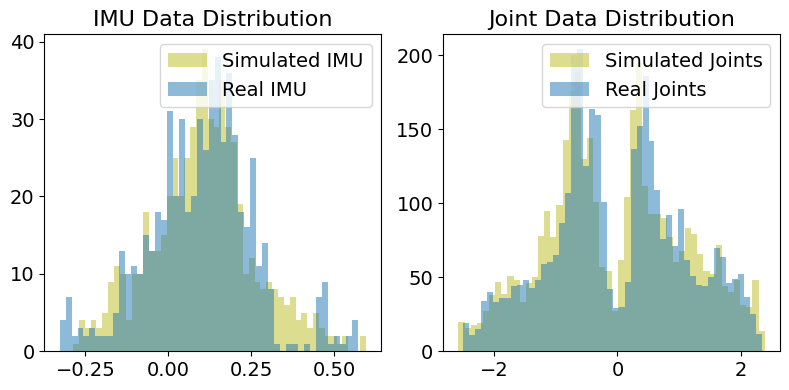

In [40]:
# plot the histogram
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs = axs.ravel()
axs[0].hist(sim_imu.values.flatten(), bins=50, alpha=0.5, label='Simulated IMU',color='tab:olive')
axs[0].hist(real_imu.values.flatten(), bins=50, alpha=0.5, label='Real IMU', color='tab:blue')
axs[0].set_title('IMU Data Distribution', fontsize =16)
axs[0].legend(fontsize=14)
axs[1].hist(sim_joints.values.flatten(), bins=50, alpha=0.5, label='Simulated Joints', color='tab:olive')
axs[1].hist(real_joints.values.flatten(), bins=50, alpha=0.5, label='Real Joints', color='tab:blue')
axs[1].set_title('Joint Data Distribution', fontsize =16)
axs[1].legend(fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

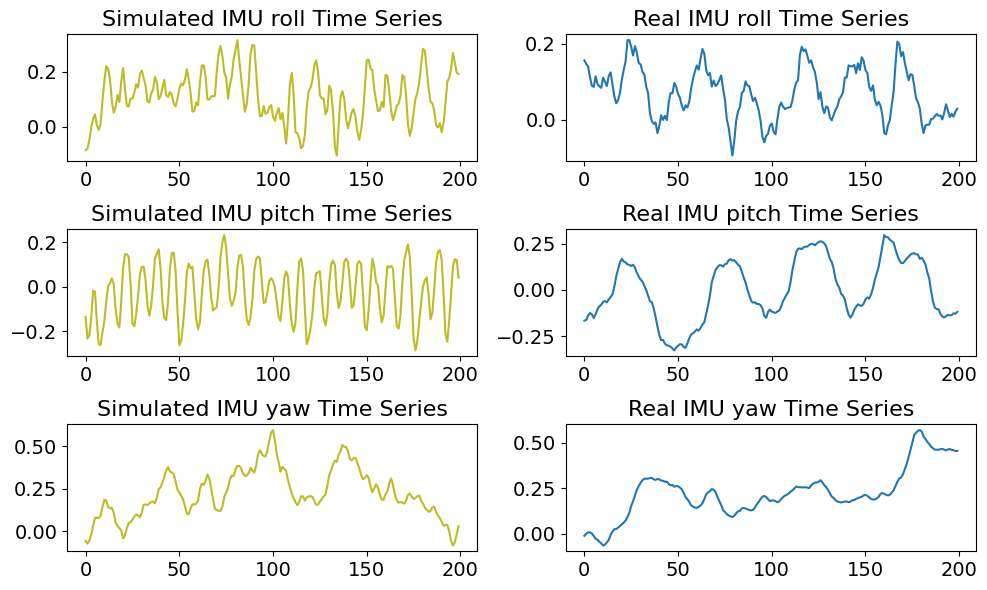

In [30]:
# plot the time series
fig, axs = plt.subplots(3, 2, figsize=(10, 6))
axs = axs.ravel()
axs[0].plot(sim_imu.index, sim_imu.iloc[:,0], color='tab:olive')
axs[0].set_title('Simulated IMU roll Time Series', fontsize =16)
axs[1].plot(real_imu.index, real_imu.iloc[:,0], color='tab:blue')
axs[1].set_title('Real IMU roll Time Series', fontsize =16)
axs[2].plot(sim_imu.index, sim_imu.iloc[:,1], color='tab:olive')
axs[2].set_title('Simulated IMU pitch Time Series', fontsize =16)
axs[3].plot(real_imu.index, real_imu.iloc[:,1], color='tab:blue')
axs[3].set_title('Real IMU pitch Time Series', fontsize =16)
axs[4].plot(sim_imu.index, sim_imu.iloc[:,2], color='tab:olive')
axs[4].set_title('Simulated IMU yaw Time Series', fontsize =16)
axs[5].plot(real_imu.index, real_imu.iloc[:,2], color='tab:blue')
axs[5].set_title('Real IMU yaw Time Series', fontsize =16)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()


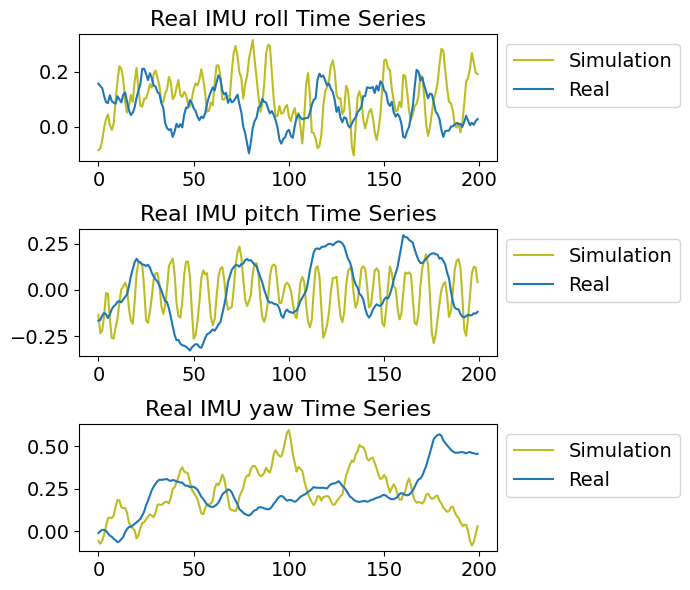

In [39]:
# plot the time series
fig, axs = plt.subplots(3, 1, figsize=(7, 6))
axs = axs.ravel()
axs[0].plot(sim_imu.index, sim_imu.iloc[:,0], color='tab:olive', label='Simulation')
axs[0].set_title('Simulated IMU roll Time Series', fontsize =16)
axs[0].plot(real_imu.index, real_imu.iloc[:,0], color='tab:blue', label='Real')
axs[0].set_title('Real IMU roll Time Series', fontsize =16)
axs[0].legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)
axs[1].plot(sim_imu.index, sim_imu.iloc[:,1], color='tab:olive', label='Simulation')
axs[1].set_title('Simulated IMU pitch Time Series', fontsize =16)
axs[1].plot(real_imu.index, real_imu.iloc[:,1], color='tab:blue', label='Real')
axs[1].set_title('Real IMU pitch Time Series', fontsize =16)
axs[1].legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)
axs[2].plot(sim_imu.index, sim_imu.iloc[:,2], color='tab:olive', label='Simulation')
axs[2].set_title('Simulated IMU yaw Time Series', fontsize =16)
axs[2].plot(real_imu.index, real_imu.iloc[:,2], color='tab:blue', label='Real')
axs[2].set_title('Real IMU yaw Time Series', fontsize =16)
axs[2].legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

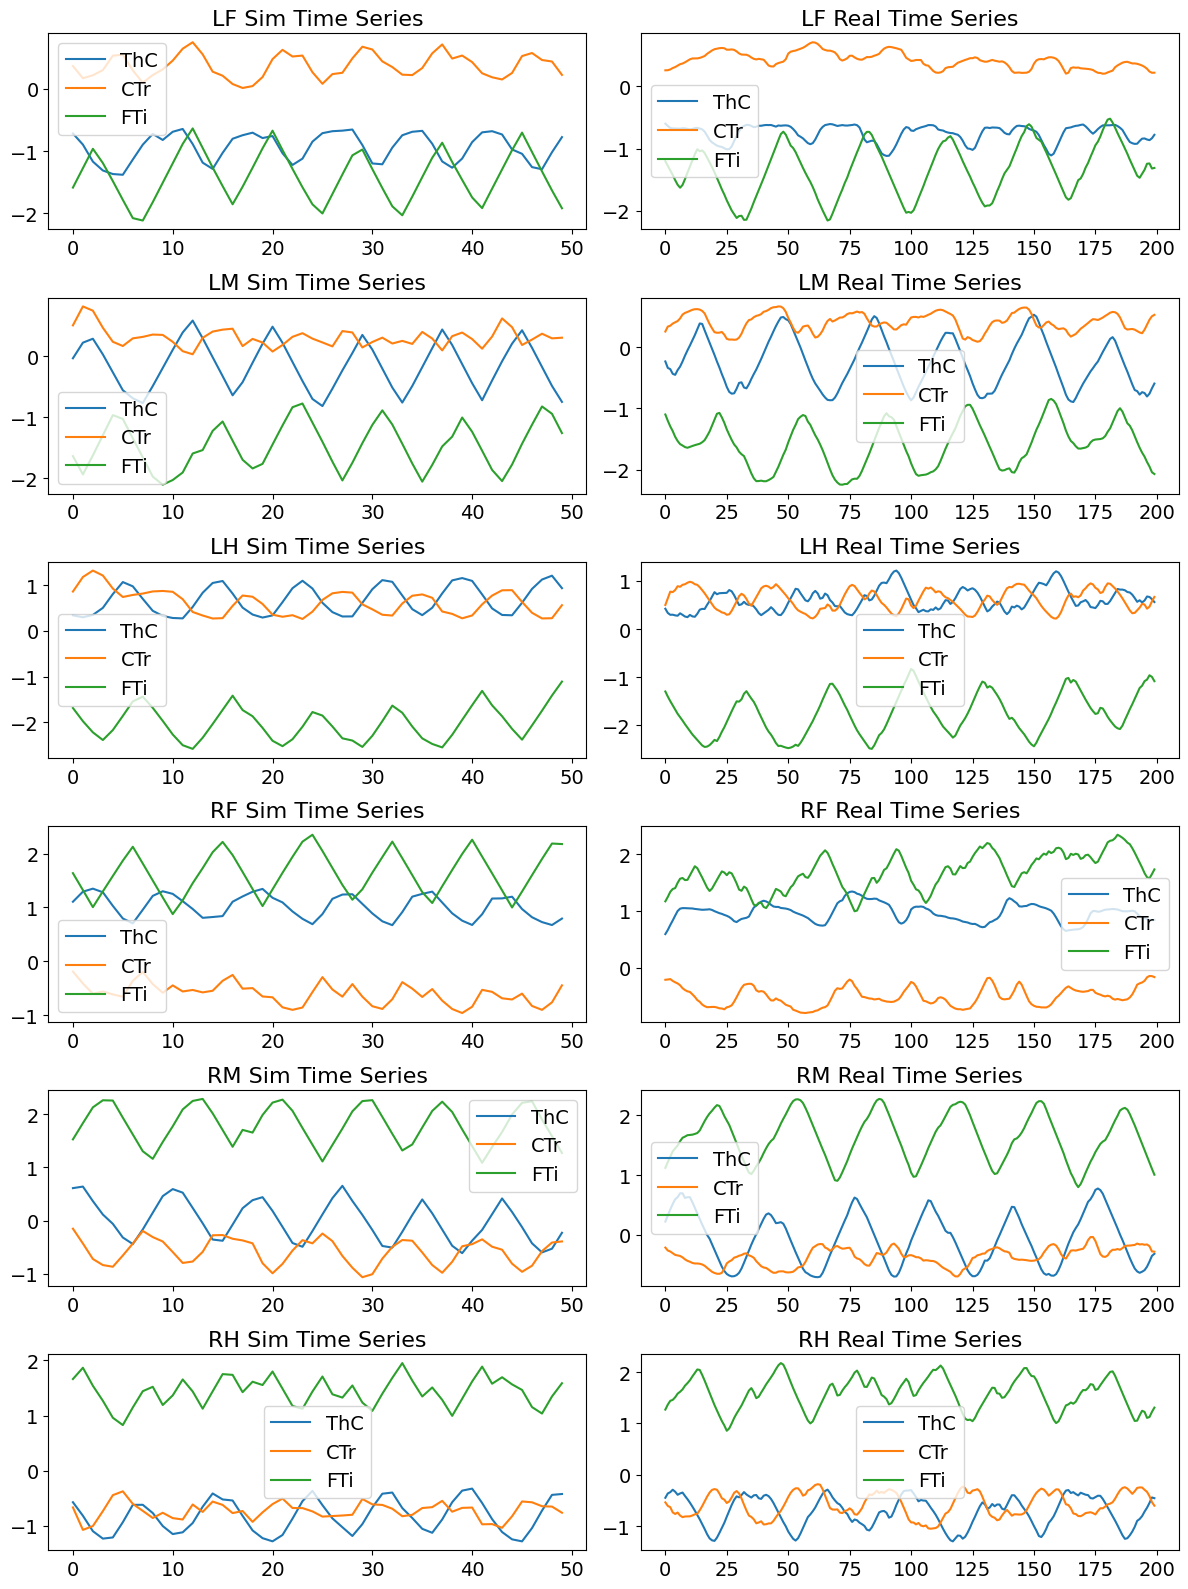

In [14]:
# plot the time series
fig, axs = plt.subplots(6, 2, figsize=(12, 16))
axs = axs.ravel()
axs[0].plot(sim_joints.index[:50], sim_joints.iloc[:50,0], label='ThC')
axs[0].plot(sim_joints.index[:50], sim_joints.iloc[:50,1], label='CTr')
axs[0].plot(sim_joints.index[:50], sim_joints.iloc[:50,2], label='FTi')
axs[0].legend(fontsize=14)
axs[0].set_title('LF Sim Time Series', fontsize =16)
axs[1].plot(real_joints.index, real_joints.iloc[:,0], label='ThC')
axs[1].plot(real_joints.index, real_joints.iloc[:,1], label='CTr')
axs[1].plot(real_joints.index, real_joints.iloc[:,2], label='FTi')
axs[1].legend(fontsize=14)
axs[1].set_title('LF Real Time Series', fontsize =16)
axs[2].plot(sim_joints.index[:50], sim_joints.iloc[:50,3], label='ThC')
axs[2].plot(sim_joints.index[:50], sim_joints.iloc[:50,4], label='CTr')
axs[2].plot(sim_joints.index[:50], sim_joints.iloc[:50,5], label='FTi')
axs[2].legend(fontsize=14)
axs[2].set_title('LM Sim Time Series', fontsize =16)
axs[3].plot(real_joints.index, real_joints.iloc[:,3], label='ThC')
axs[3].plot(real_joints.index, real_joints.iloc[:,4], label='CTr')
axs[3].plot(real_joints.index, real_joints.iloc[:,5], label='FTi')
axs[3].legend(fontsize=14)
axs[3].set_title('LM Real Time Series', fontsize =16)
axs[4].plot(sim_joints.index[:50], sim_joints.iloc[:50,6], label='ThC')
axs[4].plot(sim_joints.index[:50], sim_joints.iloc[:50,7], label='CTr')
axs[4].plot(sim_joints.index[:50], sim_joints.iloc[:50,8], label='FTi')
axs[4].legend(fontsize=14)
axs[4].set_title('LH Sim Time Series', fontsize =16)
axs[5].plot(real_joints.index, real_joints.iloc[:,6], label='ThC')
axs[5].plot(real_joints.index, real_joints.iloc[:,7], label='CTr')
axs[5].plot(real_joints.index, real_joints.iloc[:,8], label='FTi')
axs[5].legend(fontsize=14)
axs[5].set_title('LH Real Time Series', fontsize =16)

axs[6].plot(sim_joints.index[:50], sim_joints.iloc[:50,9], label='ThC')
axs[6].plot(sim_joints.index[:50], sim_joints.iloc[:50,10], label='CTr')
axs[6].plot(sim_joints.index[:50], sim_joints.iloc[:50,11], label='FTi')
axs[6].legend(fontsize=14)
axs[6].set_title('RF Sim Time Series', fontsize =16)
axs[7].plot(real_joints.index, real_joints.iloc[:,9], label='ThC')
axs[7].plot(real_joints.index, real_joints.iloc[:,10], label='CTr')
axs[7].plot(real_joints.index, real_joints.iloc[:,11], label='FTi')
axs[7].legend(fontsize=14)
axs[7].set_title('RF Real Time Series', fontsize =16)
axs[8].plot(sim_joints.index[:50], sim_joints.iloc[:50,12], label='ThC')
axs[8].plot(sim_joints.index[:50], sim_joints.iloc[:50,13], label='CTr')
axs[8].plot(sim_joints.index[:50], sim_joints.iloc[:50,14], label='FTi')
axs[8].legend(fontsize=14)
axs[8].set_title('RM Sim Time Series', fontsize =16)
axs[9].plot(real_joints.index, real_joints.iloc[:,12], label='ThC')
axs[9].plot(real_joints.index, real_joints.iloc[:,13], label='CTr')
axs[9].plot(real_joints.index, real_joints.iloc[:,14], label='FTi')
axs[9].legend(fontsize=14)
axs[9].set_title('RM Real Time Series', fontsize =16)
axs[10].plot(sim_joints.index[:50], sim_joints.iloc[:50,15], label='ThC')
axs[10].plot(sim_joints.index[:50], sim_joints.iloc[:50,16], label='CTr')
axs[10].plot(sim_joints.index[:50], sim_joints.iloc[:50,17], label='FTi')
axs[10].legend(fontsize=14)
axs[10].set_title('RH Sim Time Series', fontsize =16)
axs[11].plot(real_joints.index, real_joints.iloc[:,15], label='ThC')
axs[11].plot(real_joints.index, real_joints.iloc[:,16], label='CTr')
axs[11].plot(real_joints.index, real_joints.iloc[:,17], label='FTi')
axs[11].legend(fontsize=14)
axs[11].set_title('RH Real Time Series', fontsize =16)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

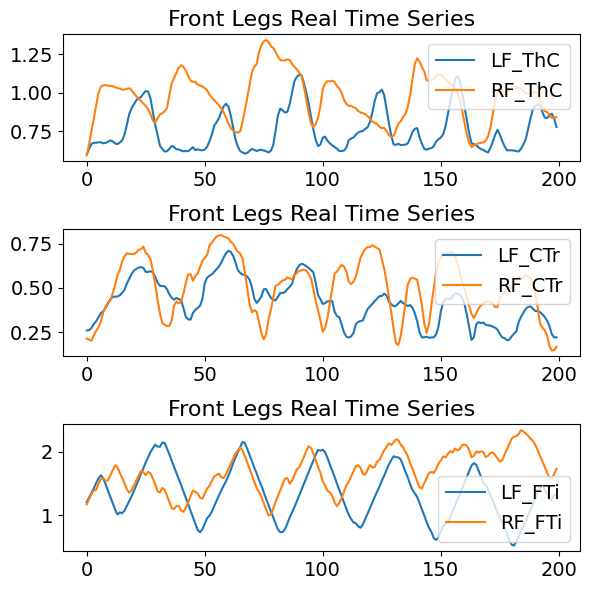

In [45]:
# plot the time series
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
axs = axs.ravel()

axs[0].plot(real_joints.index, real_joints.iloc[:,0]*(-1), label='LF_ThC')
axs[0].plot(real_joints.index, real_joints.iloc[:,9], label='RF_ThC')
axs[0].legend(fontsize=14)
axs[0].set_title('Front Legs Real Time Series', fontsize =16)

axs[1].plot(real_joints.index, real_joints.iloc[:,1], label='LF_CTr')
axs[1].plot(real_joints.index, real_joints.iloc[:,10]*(-1), label='RF_CTr')
axs[1].legend(fontsize=14)
axs[1].set_title('Front Legs Real Time Series', fontsize =16)

axs[2].plot(real_joints.index, real_joints.iloc[:,2]*(-1), label='LF_FTi')
axs[2].plot(real_joints.index, real_joints.iloc[:,11], label='RF_FTi')
axs[2].legend(fontsize=14)
axs[2].set_title('Front Legs Real Time Series', fontsize =16)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

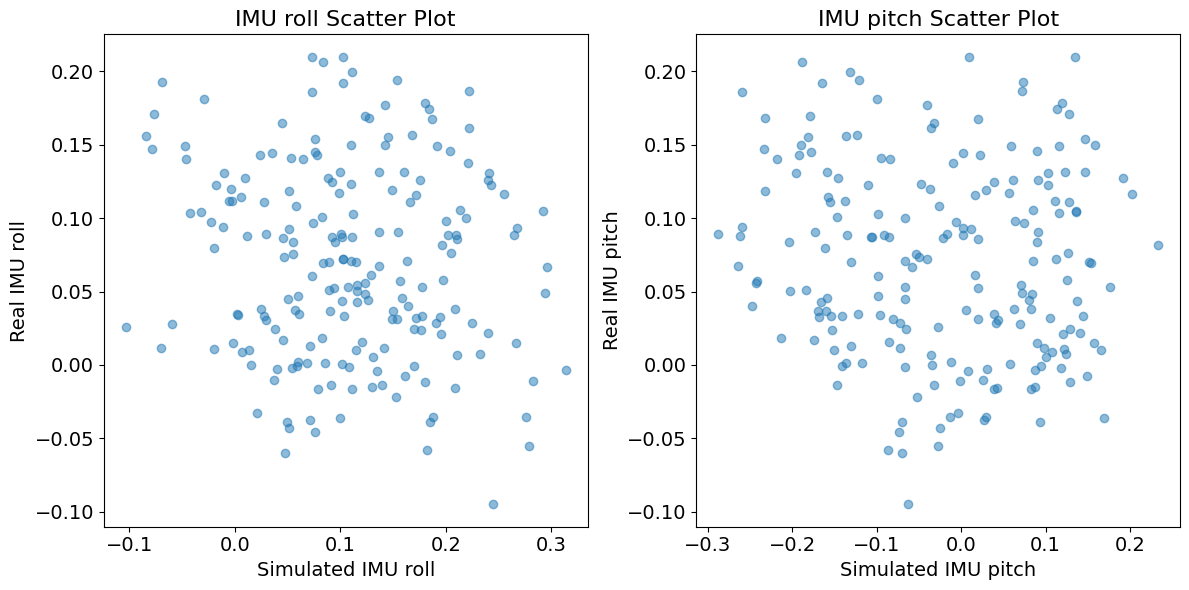

In [13]:
# plot the scatter plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
axs[0].scatter(sim_imu.iloc[:,0], real_imu.iloc[:len(sim_imu),0], alpha=0.5)
axs[0].set_title('IMU roll Scatter Plot', fontsize =16)
axs[0].set_xlabel('Simulated IMU roll', fontsize=14)
axs[0].set_ylabel('Real IMU roll', fontsize=14)
axs[1].scatter(sim_imu.iloc[:,1], real_imu.iloc[:len(sim_imu),0], alpha=0.5)
axs[1].set_title('IMU pitch Scatter Plot', fontsize =16)
axs[1].set_xlabel('Simulated IMU pitch', fontsize=14)
axs[1].set_ylabel('Real IMU pitch', fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()
